# Shopstream - Time-Series Analysis 3.2

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('ecommerce_orders_dataset.csv')

In [3]:
df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,...,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,...,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,...,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,...,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,...,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,...,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 30000 non-null  int64  
 1   Customer_ID              30000 non-null  str    
 2   Order_Date               30000 non-null  str    
 3   Year                     30000 non-null  int64  
 4   Month                    30000 non-null  int64  
 5   Day                      30000 non-null  int64  
 6   Day_Of_Week              30000 non-null  str    
 7   Quarter                  30000 non-null  int64  
 8   Customer_Age             30000 non-null  int64  
 9   Customer_Gender          30000 non-null  str    
 10  Country                  30000 non-null  str    
 11  City                     30000 non-null  str    
 12  Customer_Segment         30000 non-null  str    
 13  Product_ID               30000 non-null  str    
 14  Product_Category         30000 no

In [5]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (30000, 41)

Columns:
['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day', 'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country', 'City', 'Customer_Segment', 'Product_ID', 'Product_Category', 'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity', 'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost', 'Tax_Amount', 'Order_Amount', 'Payment_Method', 'Device_Type', 'Traffic_Source', 'Membership_Status', 'Shipping_Method', 'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned', 'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent', 'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order']


## Convert date and inspect

In [6]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df = df.sort_values('Order_Date')

print("Start date:", df['Order_Date'].min())
print("End date:", df['Order_Date'].max())

print("\nNumber of unique dates:",
      df['Order_Date'].nunique())

Start date: 2023-01-01 00:00:00
End date: 2026-12-31 00:00:00

Number of unique dates: 1461


In [7]:
df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,...,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,...,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
26,601965,CUST003310,2023-01-01,2023,1,1,Sunday,1,28,Male,...,4,Delivered,No,3.8,262.62,22.50,3.51,Winter,No,No
25,608217,CUST006377,2023-01-01,2023,1,1,Sunday,1,23,Female,...,0,Delivered,No,5.0,8860.04,12.26,107.21,Winter,No,Yes
24,621210,CUST001253,2023-01-01,2023,1,1,Sunday,1,24,Female,...,9,Delivered,No,4.6,2279.79,17.02,21.51,Winter,No,No
23,617522,CUST000025,2023-01-01,2023,1,1,Sunday,1,31,Male,...,5,Delivered,No,4.3,4086.69,15.99,237.91,Winter,No,Yes


In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 30000 entries, 0 to 29999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_ID                 30000 non-null  int64         
 1   Customer_ID              30000 non-null  str           
 2   Order_Date               30000 non-null  datetime64[us]
 3   Year                     30000 non-null  int64         
 4   Month                    30000 non-null  int64         
 5   Day                      30000 non-null  int64         
 6   Day_Of_Week              30000 non-null  str           
 7   Quarter                  30000 non-null  int64         
 8   Customer_Age             30000 non-null  int64         
 9   Customer_Gender          30000 non-null  str           
 10  Country                  30000 non-null  str           
 11  City                     30000 non-null  str           
 12  Customer_Segment         30000 non-null  str    

## Keeping "Order_Amount" as the target

In [9]:
daily_sales = (
    df.groupby('Order_Date')['Order_Amount']
      .sum()
      .sort_index()
)

daily_sales.name = 'Sales'

print(daily_sales.head())
print("\nNumber of observations:", len(daily_sales))

Order_Date
2023-01-01    10026.40
2023-01-02     8261.28
2023-01-03     8260.24
2023-01-04     8649.10
2023-01-05     7342.03
Name: Sales, dtype: float64

Number of observations: 1461


# Checking Time-Series Frequency

## Checking Missing Dates

In [10]:
full_date_range = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq='D'
)

missing_dates = full_date_range.difference(
    daily_sales.index
)

print("Expected number of dates:",
      len(full_date_range))

print("Actual number of dates:",
      len(daily_sales))

print("Missing dates:",
      len(missing_dates))

if len(missing_dates) > 0:
    print(missing_dates)

Expected number of dates: 1461
Actual number of dates: 1461
Missing dates: 0


## Convert explicitly to daily frequency

In [11]:
daily_sales = daily_sales.reindex(
    full_date_range
)

daily_sales.index.name = 'Order_Date'

daily_sales = daily_sales.asfreq('D')

print(daily_sales.head())
print(daily_sales.tail())

Order_Date
2023-01-01    10026.40
2023-01-02     8261.28
2023-01-03     8260.24
2023-01-04     8649.10
2023-01-05     7342.03
Freq: D, Name: Sales, dtype: float64
Order_Date
2026-12-27    2010.75
2026-12-28    3937.11
2026-12-29    9613.56
2026-12-30    9567.89
2026-12-31    5151.79
Freq: D, Name: Sales, dtype: float64


In [12]:
# If a date has no orders, we treat its sales as zero:

daily_sales = daily_sales.fillna(0)

## Saving the final time-series dataset

In [13]:
daily_sales.to_csv(
    "daily_sales_time_series.csv"
)

print("Saved: daily_sales_time_series.csv")

Saved: daily_sales_time_series.csv


# Basic Descriptive Statistics 

In [14]:
daily_sales.head()

Order_Date
2023-01-01    10026.40
2023-01-02     8261.28
2023-01-03     8260.24
2023-01-04     8649.10
2023-01-05     7342.03
Freq: D, Name: Sales, dtype: float64

In [15]:
daily_sales.shape

(1461,)

In [16]:
daily_sales.describe()

count     1461.000000
mean      7782.370972
std       3239.887466
min       1203.860000
25%       5484.230000
50%       7389.410000
75%       9758.330000
max      26576.790000
Name: Sales, dtype: float64

In [17]:
daily_sales.info()

<class 'pandas.Series'>
DatetimeIndex: 1461 entries, 2023-01-01 to 2026-12-31
Freq: D
Series name: Sales
Non-Null Count  Dtype  
--------------  -----  
1461 non-null   float64
dtypes: float64(1)
memory usage: 22.8 KB


# Plotting the Complete Time Series

## Daily sales plot

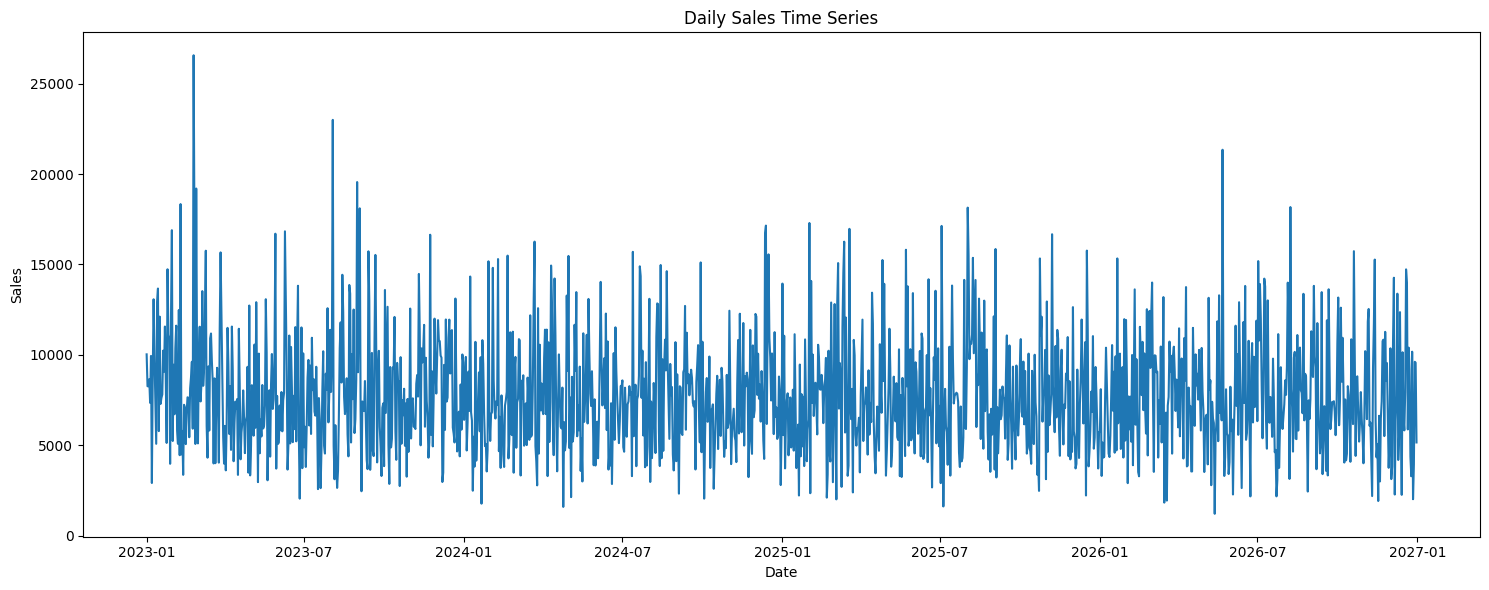

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales.index,
    daily_sales.values
)

plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    "01_daily_sales_time_series.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Rolling statistics

Rolling statistics help identify:

Trend
Changing variance
Volatility
Local fluctuations

In [19]:
rolling_7 = daily_sales.rolling(7).mean()
rolling_30 = daily_sales.rolling(30).mean()
rolling_90 = daily_sales.rolling(90).mean()

rolling_7_std = daily_sales.rolling(7).std()
rolling_30_std = daily_sales.rolling(30).std()
rolling_90_std = daily_sales.rolling(90).std()

## Rolling Mean Plot

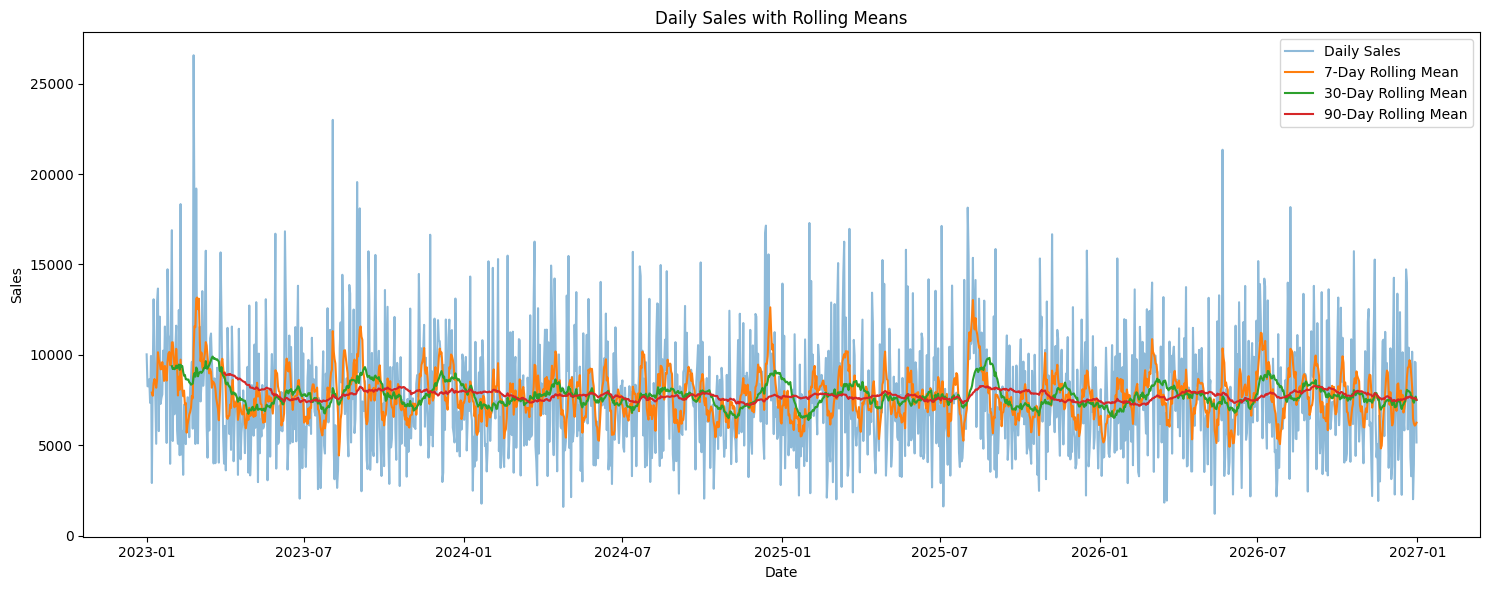

In [20]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales.index,
    daily_sales,
    label='Daily Sales',
    alpha=0.5
)

plt.plot(
    daily_sales.index,
    rolling_7,
    label='7-Day Rolling Mean'
)

plt.plot(
    daily_sales.index,
    rolling_30,
    label='30-Day Rolling Mean'
)

plt.plot(
    daily_sales.index,
    rolling_90,
    label='90-Day Rolling Mean'
)

plt.title("Daily Sales with Rolling Means")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "02_rolling_means.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Rolling standard deviation

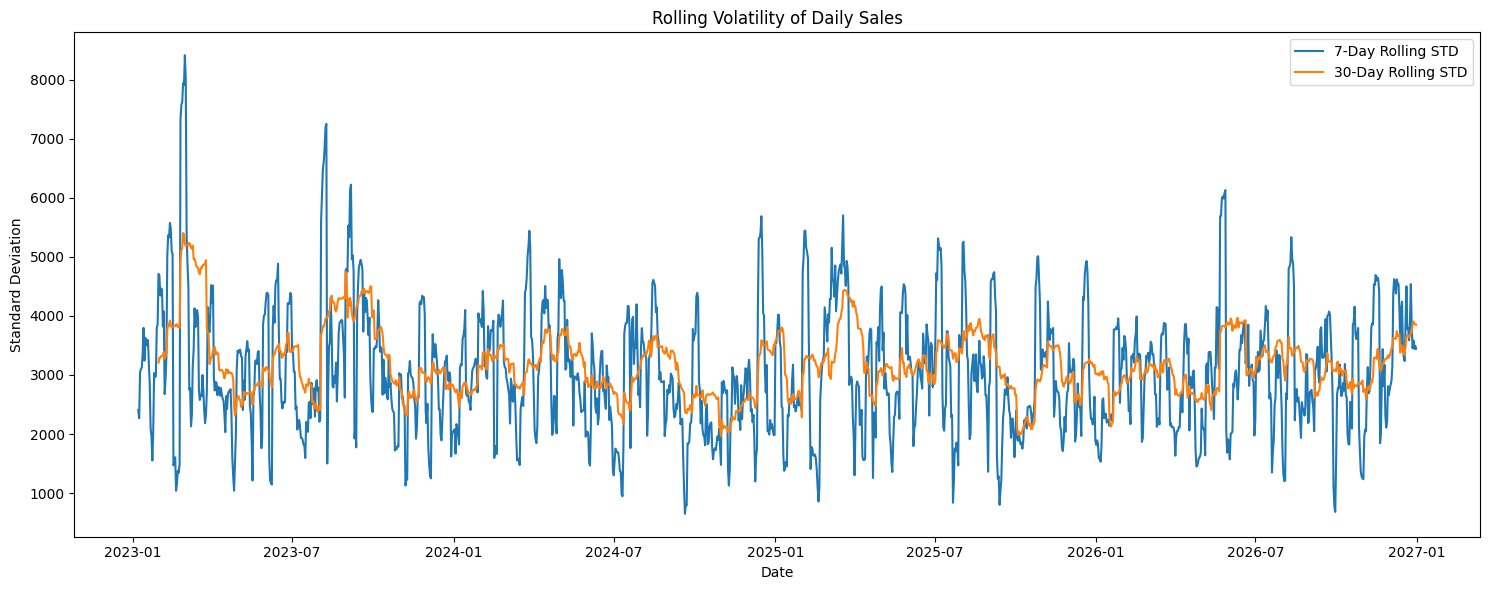

In [21]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales.index,
    rolling_7_std,
    label='7-Day Rolling STD'
)

plt.plot(
    daily_sales.index,
    rolling_30_std,
    label='30-Day Rolling STD'
)

plt.title("Rolling Volatility of Daily Sales")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")

plt.legend()

plt.tight_layout()

plt.savefig(
    "03_rolling_standard_deviation.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Distribution of sales

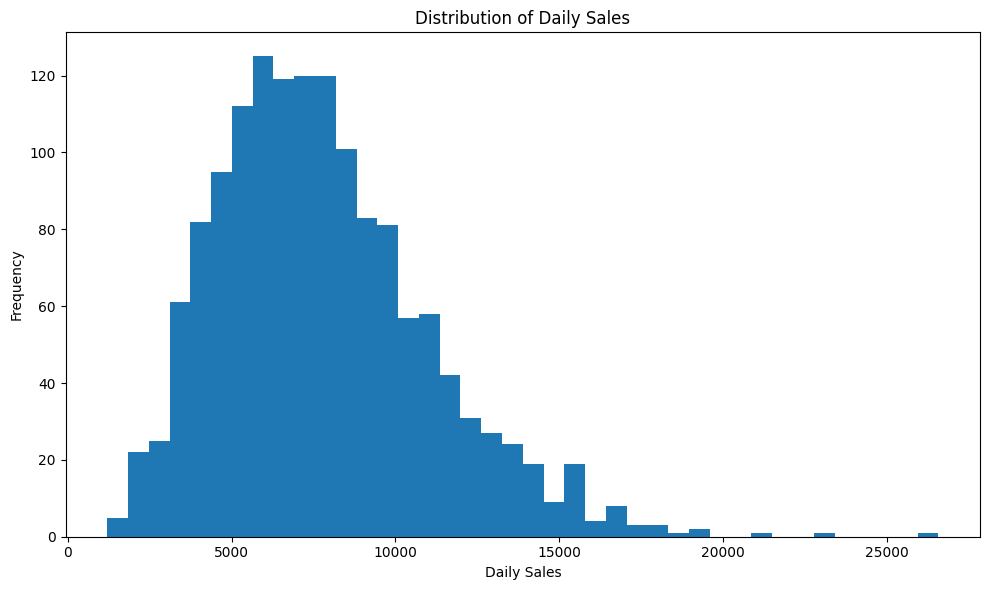

In [22]:
plt.figure(figsize=(10, 6))

plt.hist(
    daily_sales,
    bins=40
)

plt.title("Distribution of Daily Sales")
plt.xlabel("Daily Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "04_sales_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Boxplot and outlier analysis

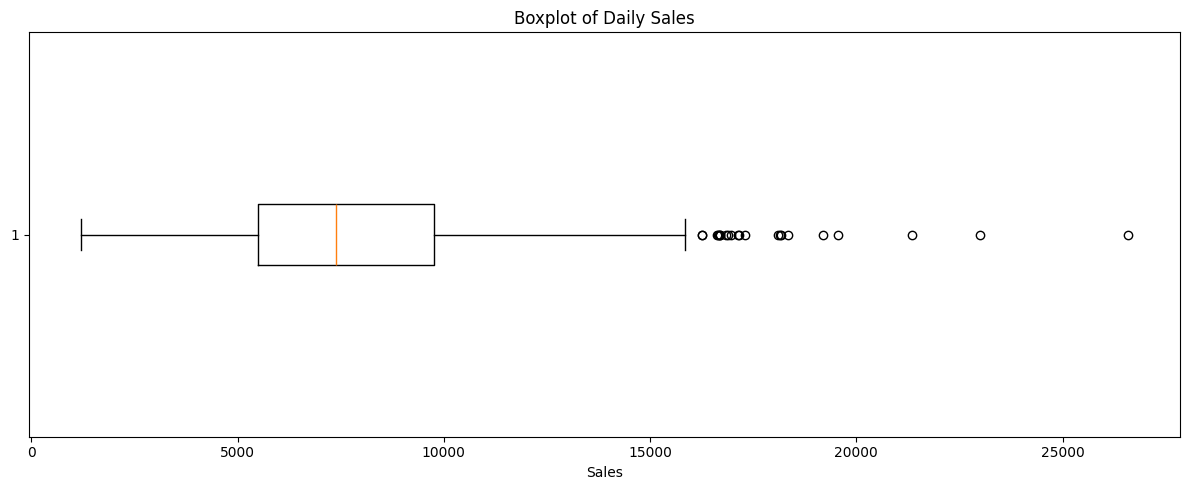

In [23]:
plt.figure(figsize=(12, 5))

plt.boxplot(
    daily_sales,
    vert=False
)

plt.title("Boxplot of Daily Sales")
plt.xlabel("Sales")

plt.tight_layout()

plt.savefig(
    "05_sales_boxplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Monthly aggregation

Even though the model remains daily, monthly aggregation is useful for understanding the longer-term trend.

In [24]:
monthly_sales = daily_sales.resample('ME').sum()

print(monthly_sales.head())

Order_Date
2023-01-31    286490.57
2023-02-28    253970.94
2023-03-31    269086.84
2023-04-30    208666.60
2023-05-31    237289.67
Freq: ME, Name: Sales, dtype: float64


In [25]:
monthly_sales.shape

(48,)

In [26]:
monthly_sales.info()

<class 'pandas.Series'>
DatetimeIndex: 48 entries, 2023-01-31 to 2026-12-31
Freq: ME
Series name: Sales
Non-Null Count  Dtype  
--------------  -----  
48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes


In [27]:
monthly_sales.describe()

count        48.000000
mean     236875.916458
std       19313.350876
min      205509.570000
25%      224133.332500
50%      234342.335000
75%      247462.717500
max      291993.150000
Name: Sales, dtype: float64

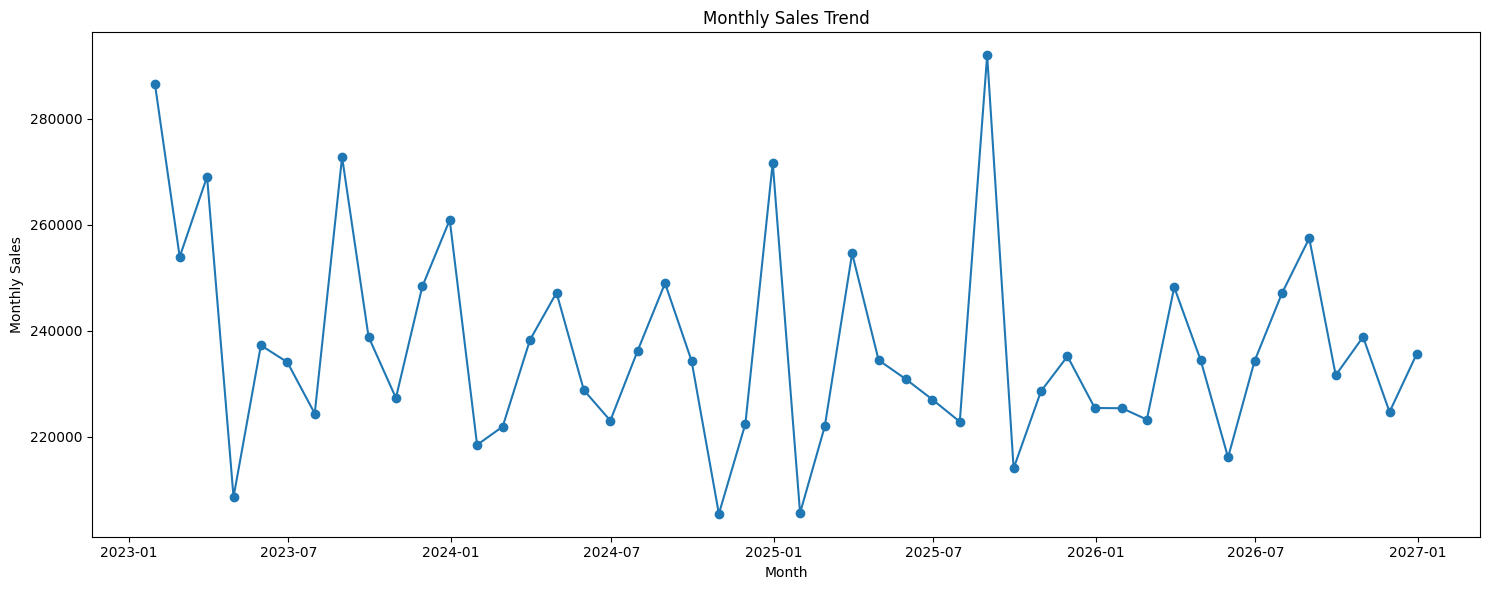

In [28]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Monthly Sales")

plt.tight_layout()

plt.savefig(
    "06_monthly_sales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Yearly Aggregation

In [29]:
yearly_sales = daily_sales.resample('YE').sum()

print(yearly_sales)

Order_Date
2023-12-31    2962427.11
2024-12-31    2797262.51
2025-12-31    2792985.70
2026-12-31    2817368.67
Freq: YE-DEC, Name: Sales, dtype: float64


In [30]:
yearly_sales.head()

Order_Date
2023-12-31    2962427.11
2024-12-31    2797262.51
2025-12-31    2792985.70
2026-12-31    2817368.67
Freq: YE-DEC, Name: Sales, dtype: float64

In [31]:
yearly_sales.shape

(4,)

In [32]:
yearly_sales.info()

<class 'pandas.Series'>
DatetimeIndex: 4 entries, 2023-12-31 to 2026-12-31
Freq: YE-DEC
Series name: Sales
Non-Null Count  Dtype  
--------------  -----  
4 non-null      float64
dtypes: float64(1)
memory usage: 64.0 bytes


In [33]:
yearly_sales.describe()

count    4.000000e+00
mean     2.842511e+06
std      8.064778e+04
min      2.792986e+06
25%      2.796193e+06
50%      2.807316e+06
75%      2.853633e+06
max      2.962427e+06
Name: Sales, dtype: float64

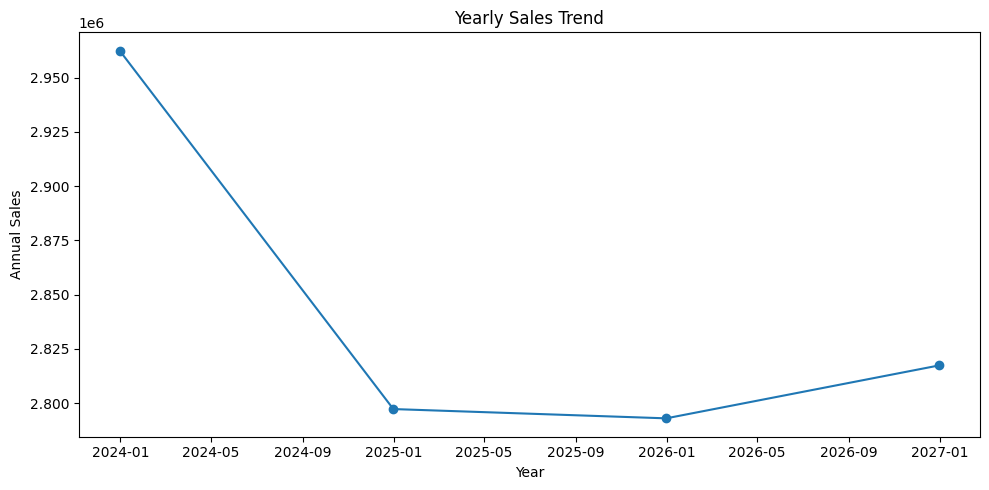

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker='o'
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Annual Sales")

plt.tight_layout()

plt.savefig(
    "07_yearly_sales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Day-of-week seasonality

This is especially important because we have daily e-commerce data.

In [35]:
weekday_sales = daily_sales.groupby(
    daily_sales.index.dayofweek
).mean()

weekday_names = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

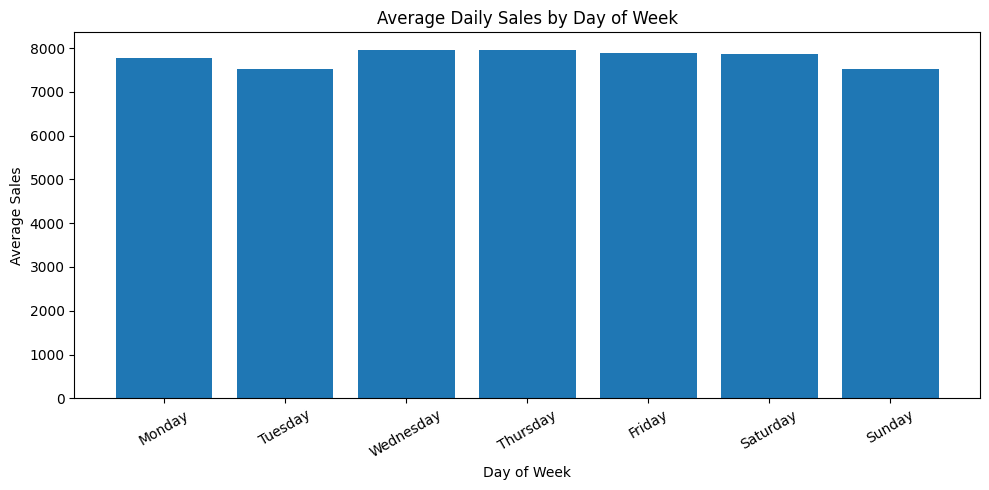

In [36]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_names,
    weekday_sales.values
)

plt.title("Average Daily Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "08_weekly_seasonality.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Monthly seasonality

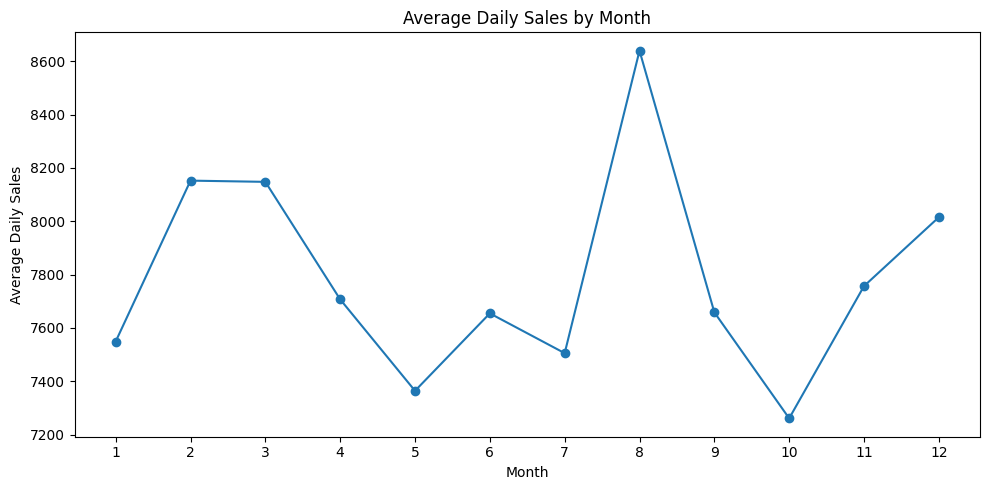

In [37]:
monthly_seasonality = daily_sales.groupby(
    daily_sales.index.month
).mean()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker='o'
)

plt.title("Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")

plt.xticks(range(1, 13))

plt.tight_layout()

plt.savefig(
    "09_monthly_seasonality.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Seasonal decomposition

We'll examine:

Observed

Trend

Seasonality

Residual

## Weekly decomposition

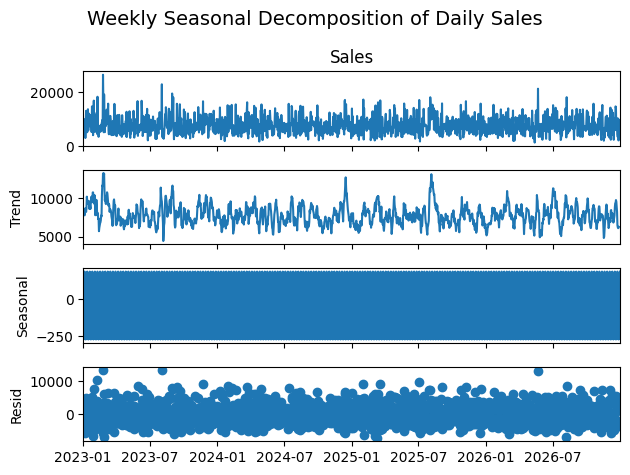

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_weekly = seasonal_decompose(
    daily_sales,
    model='additive',
    period=7
)

fig = decomposition_weekly.plot()

fig.suptitle(
    "Weekly Seasonal Decomposition of Daily Sales",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "10_weekly_seasonal_decomposition.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Yearly/annual decomposition

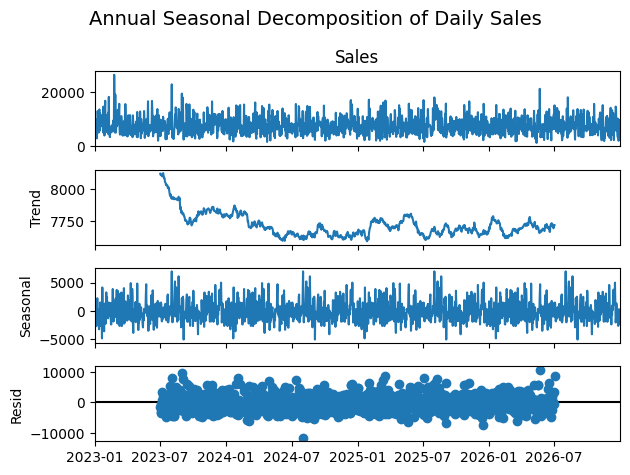

In [39]:
decomposition_yearly = seasonal_decompose(
    daily_sales,
    model='additive',
    period=365
)

fig = decomposition_yearly.plot()

fig.suptitle(
    "Annual Seasonal Decomposition of Daily Sales",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "11_annual_seasonal_decomposition.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Log transformation

Sales data can sometimes have increasing variance as the sales level increases.

We'll inspect a log-transformed version.

In [40]:
import numpy as np

log_sales = np.log1p(daily_sales)

In [41]:
log_sales.head()

Order_Date
2023-01-01    9.213077
2023-01-02    9.019456
2023-01-03    9.019330
2023-01-04    9.065326
2023-01-05    8.901507
Freq: D, Name: Sales, dtype: float64

In [42]:
log_sales.shape

(1461,)

In [43]:
log_sales.info()

<class 'pandas.Series'>
DatetimeIndex: 1461 entries, 2023-01-01 to 2026-12-31
Freq: D
Series name: Sales
Non-Null Count  Dtype  
--------------  -----  
1461 non-null   float64
dtypes: float64(1)
memory usage: 22.8 KB


In [44]:
log_sales.describe()

count    1461.000000
mean        8.870887
std         0.434075
min         7.094119
25%         8.609814
50%         8.907938
75%         9.185979
max        10.187831
Name: Sales, dtype: float64

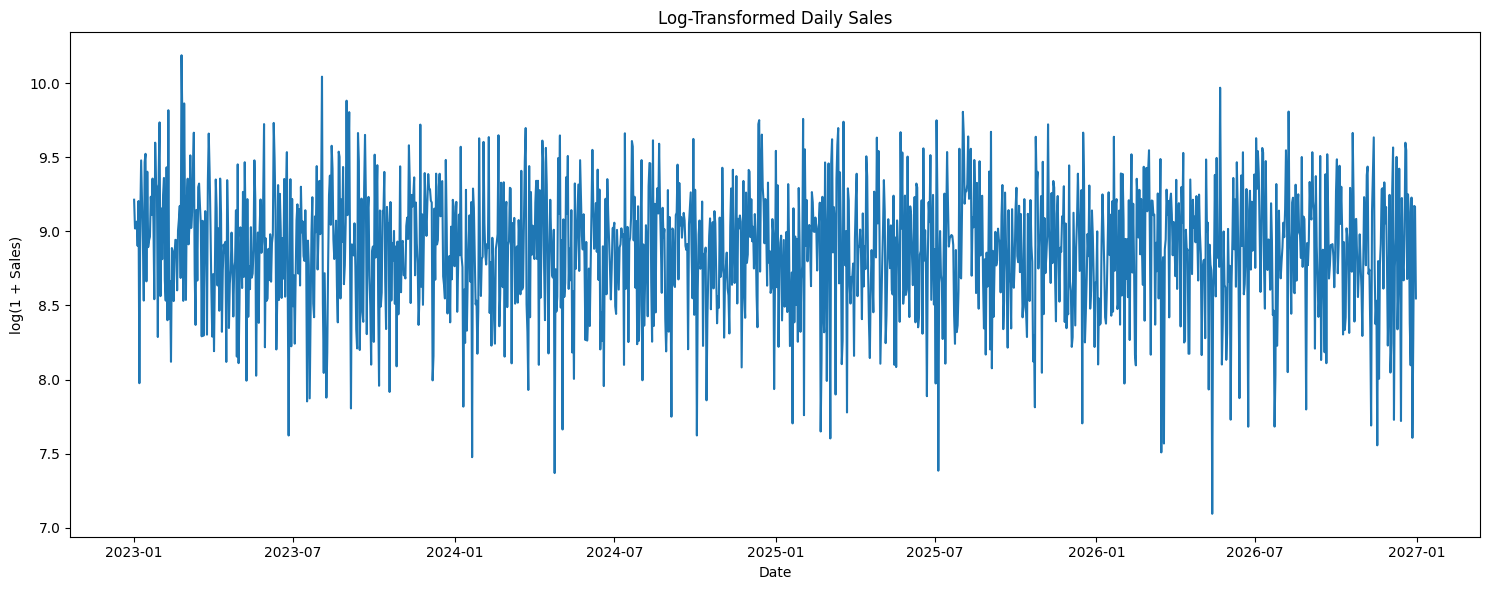

In [45]:
plt.figure(figsize=(15, 6))

plt.plot(
    log_sales.index,
    log_sales.values
)

plt.title("Log-Transformed Daily Sales")
plt.xlabel("Date")
plt.ylabel("log(1 + Sales)")

plt.tight_layout()

plt.savefig(
    "12_log_transformed_sales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Stationarity analysis

A key component of classical time-series modeling is determining whether the series is stationary.

## ADF Test

In [46]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(
    daily_sales.dropna()
)

print("ADF Statistic:",
      adf_result[0])

print("p-value:",
      adf_result[1])

print("Critical Values:")

for key, value in adf_result[4].items():
    print(
        f"{key}: {value}"
    )

ADF Statistic: -10.594843465404042
p-value: 6.388921740865201e-19
Critical Values:
1%: -3.4348678719530934
5%: -2.863535337271721
10%: -2.5678323015457787


p-value < 0.05
→ evidence against non-stationarity

p-value >= 0.05
→ insufficient evidence to reject non-stationarity

Hence, with p-value: 6.388921740865201e-19, there is evidence against non-stationarity

## First Differencing

In [47]:
sales_diff_1 = daily_sales.diff().dropna()

## Plotting first difference

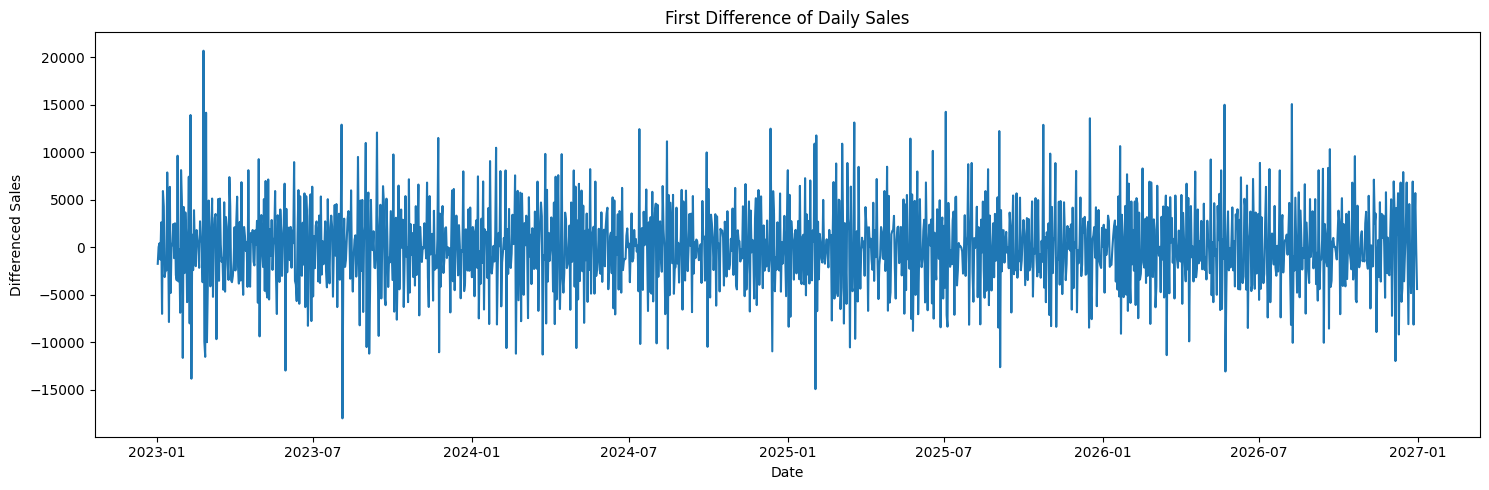

In [48]:
plt.figure(figsize=(15, 5))

plt.plot(
    sales_diff_1.index,
    sales_diff_1.values
)

plt.title("First Difference of Daily Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")

plt.tight_layout()

plt.savefig(
    "13_first_difference.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## ADF after first differencing

In [49]:
adf_diff = adfuller(
    sales_diff_1
)

print("ADF Statistic:",
      adf_diff[0])

print("p-value:",
      adf_diff[1])

ADF Statistic: -12.576930738047984
p-value: 1.948150928255821e-23


In [50]:
# The p-value was small enough earlier itself to indicate stationarity.
# Now, after first differencing, it is even smaller, further confirming stationarity.

# ACF and PACF

Essential for identifying possible ARIMA/SARIMA orders.

## ACF of original series

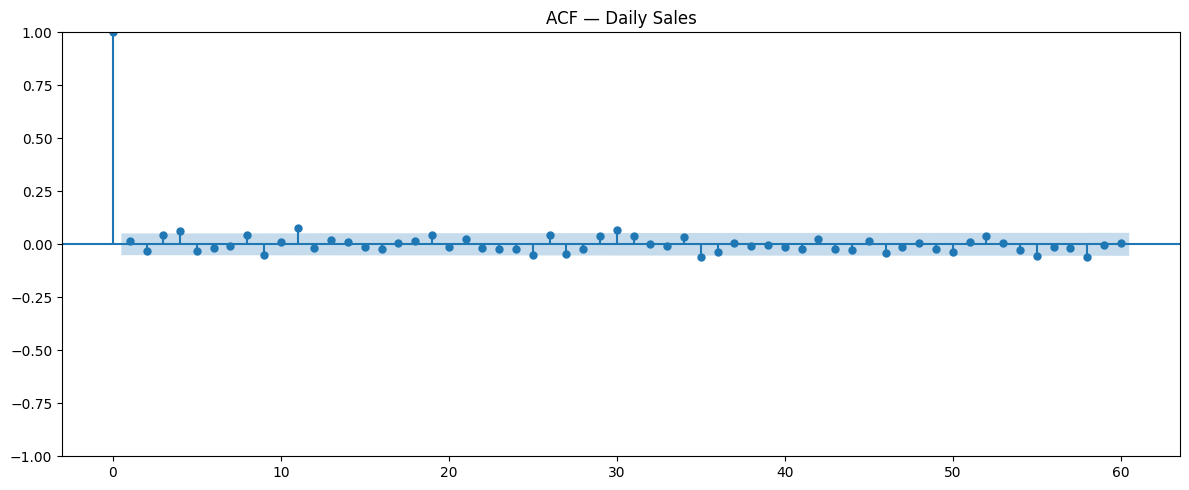

In [51]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    daily_sales,
    lags=60,
    ax=plt.gca()
)

plt.title("ACF — Daily Sales")

plt.tight_layout()

plt.savefig(
    "14_acf_original_sales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## PACF of original series 

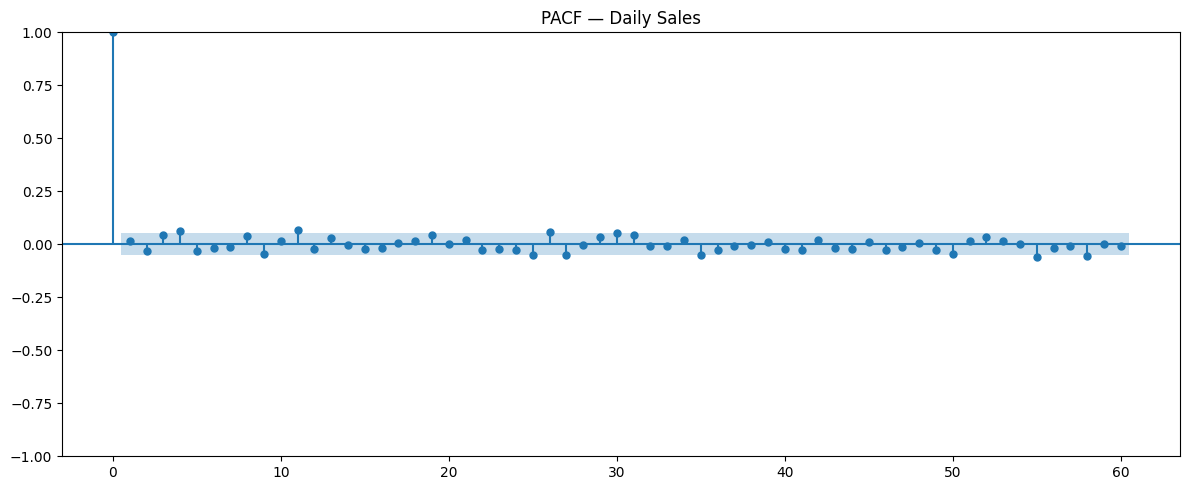

In [52]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 5))

plot_pacf(
    daily_sales,
    lags=60,
    ax=plt.gca(),
    method='ywm'
)

plt.title("PACF — Daily Sales")

plt.tight_layout()

plt.savefig(
    "15_pacf_original_sales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## ACF of differenced series

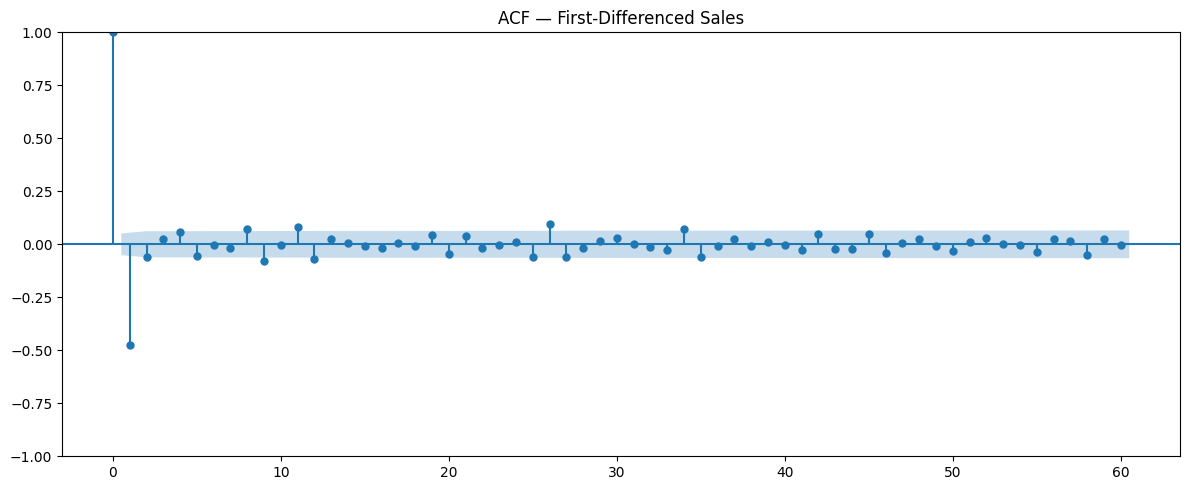

In [53]:
plt.figure(figsize=(12, 5))

plot_acf(
    sales_diff_1,
    lags=60,
    ax=plt.gca()
)

plt.title("ACF — First-Differenced Sales")

plt.tight_layout()

plt.savefig(
    "16_acf_differenced_sales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## PACF of differenced series

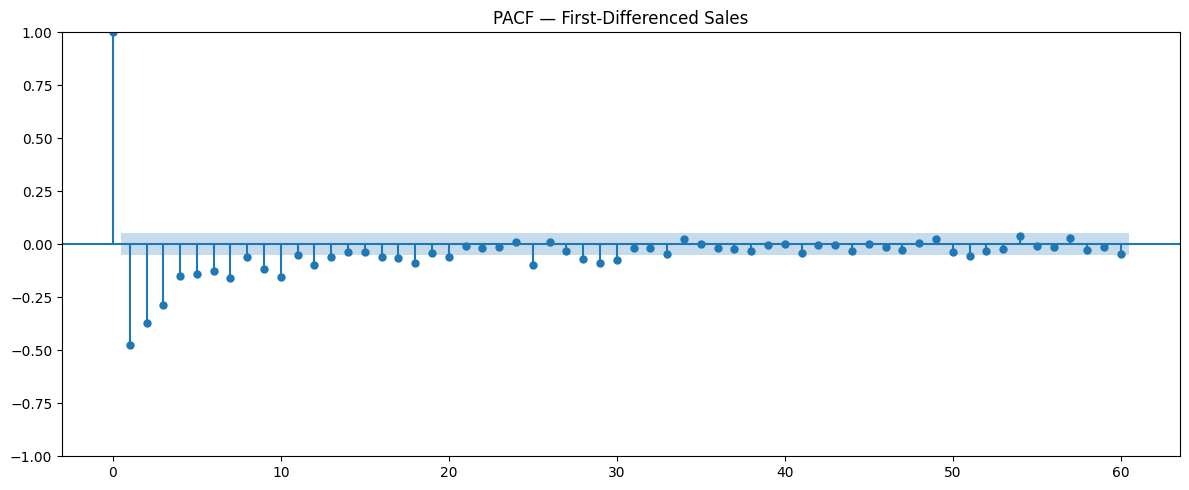

In [54]:
plt.figure(figsize=(12, 5))

plot_pacf(
    sales_diff_1,
    lags=60,
    ax=plt.gca(),
    method='ywm'
)

plt.title("PACF — First-Differenced Sales")

plt.tight_layout()

plt.savefig(
    "17_pacf_differenced_sales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Train/test split

We need a chronological split.

No train_test_split() is used.

In [55]:
test_size = 90

train = daily_sales.iloc[:-test_size]
test = daily_sales.iloc[-test_size:]

print("Training period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

print("\nTraining observations:", len(train))
print("Testing observations :", len(test))

Training period:
2023-01-01 00:00:00 to 2026-10-02 00:00:00

Testing period:
2026-10-03 00:00:00 to 2026-12-31 00:00:00

Training observations: 1371
Testing observations : 90


# Plot train/test

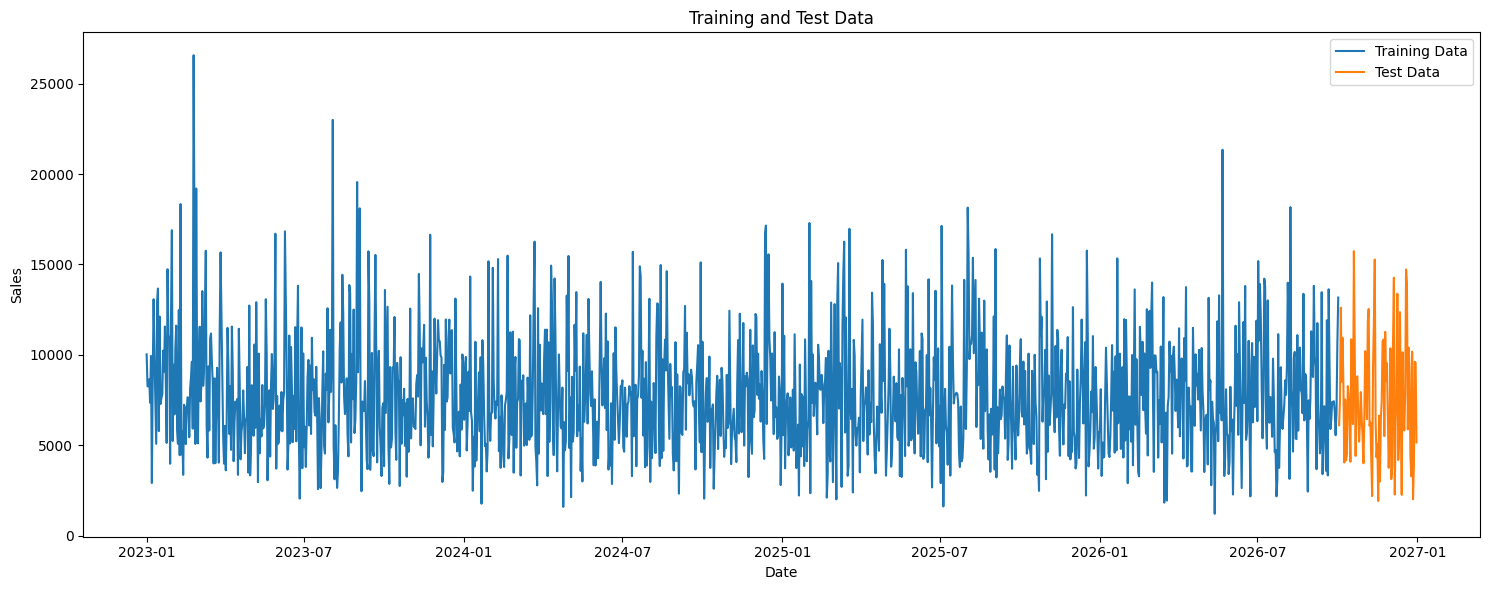

In [56]:
plt.figure(figsize=(15, 6))

plt.plot(
    train.index,
    train.values,
    label='Training Data'
)

plt.plot(
    test.index,
    test.values,
    label='Test Data'
)

plt.title("Training and Test Data")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "18_train_test_split.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Classical forecasting benchmarks

Before sophisticated models, we'll establish two baselines.

## Naive Forecast

In [57]:
naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)

# Seasonal-naive forecast

Since e-commerce sales may have weekly seasonality:

In [58]:
seasonal_naive_forecast = pd.Series(
    [
        train.iloc[-7 + (i % 7)]
        for i in range(len(test))
    ],
    index=test.index
)

# Evaluation Metrics

In [59]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    non_zero = actual != 0

    mape = np.mean(
        np.abs(
            (actual[non_zero] - predicted[non_zero])
            / actual[non_zero]
        )
    ) * 100

    return mae, rmse, mape

## Baseline evaluation

In [60]:
naive_mae, naive_rmse, naive_mape = calculate_metrics(
    test,
    naive_forecast
)

seasonal_mae, seasonal_rmse, seasonal_mape = calculate_metrics(
    test,
    seasonal_naive_forecast
)

print("Naive Forecast")
print("MAE :", naive_mae)
print("RMSE:", naive_rmse)
print("MAPE:", naive_mape)

print("\nSeasonal Naive Forecast")
print("MAE :", seasonal_mae)
print("RMSE:", seasonal_rmse)
print("MAPE:", seasonal_mape)

Naive Forecast
MAE : 5849.903333333334
RMSE: 6543.236054819935
MAPE: 122.70593736288433

Seasonal Naive Forecast
MAE : 3435.5153333333333
RMSE: 4237.154641085874
MAPE: 62.34951636371252


# ARIMA

We'll now use a classical ARIMA model.

A reasonable starting model based on the earlier stationarity/ACF/PACF analysis is:

### ARIMA(1,1,1)

In [61]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                 1371
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13020.261
Date:                Tue, 04 Aug 2026   AIC                          26046.522
Time:                        21:02:51   BIC                          26062.189
Sample:                    01-01-2023   HQIC                         26052.385
                         - 10-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0119      0.025      0.475      0.635      -0.037       0.061
ma.L1         -1.0000      0.026    -38.413      0.000      -1.051      -0.949
sigma2      1.048e+07   1.96e-09   5.35e+15      0.0

## ARIMA Forecast

In [62]:
arima_forecast = arima_result.forecast(
    steps=len(test)
)

arima_forecast.index = test.index

In [63]:
arima_forecast

Order_Date
2026-10-03    7859.375146
2026-10-04    7796.057294
2026-10-05    7795.302386
2026-10-06    7795.293385
2026-10-07    7795.293278
                 ...     
2026-12-27    7795.293277
2026-12-28    7795.293277
2026-12-29    7795.293277
2026-12-30    7795.293277
2026-12-31    7795.293277
Freq: D, Name: predicted_mean, Length: 90, dtype: float64

In [64]:
arima_forecast.shape

(90,)

In [65]:
arima_forecast.info()

<class 'pandas.Series'>
DatetimeIndex: 90 entries, 2026-10-03 to 2026-12-31
Freq: D
Series name: predicted_mean
Non-Null Count  Dtype  
--------------  -----  
90 non-null     float64
dtypes: float64(1)
memory usage: 1.4 KB


In [66]:
arima_forecast.describe()

count      90.000000
mean     7796.013889
std         6.754386
min      7795.293277
25%      7795.293277
50%      7795.293277
75%      7795.293277
max      7859.375146
Name: predicted_mean, dtype: float64

In [67]:
test

Order_Date
2026-10-03     6103.78
2026-10-04     7464.59
2026-10-05    12609.02
2026-10-06     8515.48
2026-10-07    10942.98
                ...   
2026-12-27     2010.75
2026-12-28     3937.11
2026-12-29     9613.56
2026-12-30     9567.89
2026-12-31     5151.79
Freq: D, Name: Sales, Length: 90, dtype: float64

## Evaluate ARIMA

In [68]:
arima_mae, arima_rmse, arima_mape = calculate_metrics(
    test,
    arima_forecast
)

print("ARIMA(1,1,1)")
print("----------------")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

ARIMA(1,1,1)
----------------
MAE : 2730.3765455070543
RMSE: 3288.723654284304
MAPE: 51.6379991703256


# SARIMA

For daily e-commerce data, weekly seasonality is very important.

We'll therefore use:

SARIMA(1,1,1)(1,1,1,7)

where:

(1,1,1) = non-seasonal ARIMA

(1,1,1,7) = weekly seasonal component

7 = seven-day seasonal period

In [69]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(
    disp=False
)

print(sarima_result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                 1371
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -13097.902
Date:                           Tue, 04 Aug 2026   AIC                          26205.804
Time:                                   21:02:54   BIC                          26231.858
Sample:                               01-01-2023   HQIC                         26215.560
                                    - 10-02-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0128      0.060      0.212      0.832      -0.106       0.131
ma.L1         -0.9932      0.016    -63.392

## SARIMA forecast

In [70]:
sarima_forecast = sarima_result.forecast(
    steps=len(test)
)

sarima_forecast.index = test.index

In [71]:
sarima_forecast.head()

Order_Date
2026-10-03    8392.217731
2026-10-04    7861.508410
2026-10-05    7666.626025
2026-10-06    7729.731181
2026-10-07    7947.551399
Freq: D, Name: predicted_mean, dtype: float64

In [72]:
sarima_forecast.shape

(90,)

In [73]:
sarima_forecast.info()

<class 'pandas.Series'>
DatetimeIndex: 90 entries, 2026-10-03 to 2026-12-31
Freq: D
Series name: predicted_mean
Non-Null Count  Dtype  
--------------  -----  
90 non-null     float64
dtypes: float64(1)
memory usage: 1.4 KB


In [74]:
sarima_forecast.describe()

count      90.000000
mean     7904.699434
std       241.488424
min      7538.066352
25%      7683.208016
50%      7872.459039
75%      8134.086690
max      8392.217731
Name: predicted_mean, dtype: float64

## Evaluating SARIMA

In [75]:
sarima_mae, sarima_rmse, sarima_mape = calculate_metrics(
    test,
    sarima_forecast
)

print("SARIMA(1,1,1)(1,1,1,7)")
print("-------------------------")
print("MAE :", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

SARIMA(1,1,1)(1,1,1,7)
-------------------------
MAE : 2749.8949154573857
RMSE: 3286.0756578160945
MAPE: 52.36955953646032


# Holt-Winters / Exponential Smoothing

In [76]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=7,
    initialization_method='estimated'
)

hw_result = hw_model.fit(
    optimized=True
)

print(hw_result.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    Sales   No. Observations:                 1371
Model:             ExponentialSmoothing   SSE                    14852723871.001
Optimized:                         True   AIC                          22229.668
Trend:                         Additive   BIC                          22287.125
Seasonal:                      Additive   AICC                         22229.937
Seasonal Periods:                     7   Date:                 Tue, 04 Aug 2026
Box-Cox:                          False   Time:                         21:04:40
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level              1.4901e-08                alpha                 True
smoothing_trend          

## Holt-Winters forecast

In [77]:
hw_forecast = hw_result.forecast(
    len(test)
)

hw_forecast.index = test.index

# Evaluate Holt-Winters

In [78]:
hw_mae, hw_rmse, hw_mape = calculate_metrics(
    test,
    hw_forecast
)

print("Holt-Winters")
print("----------------")
print("MAE :", hw_mae)
print("RMSE:", hw_rmse)
print("MAPE:", hw_mape)

Holt-Winters
----------------
MAE : 2734.365710764236
RMSE: 3277.974220402479
MAPE: 51.24654568058848


# Comparing all models

In [79]:
model_results = pd.DataFrame({

    'Model': [
        'Naive',
        'Seasonal Naive',
        'ARIMA(1,1,1)',
        'SARIMA(1,1,1)(1,1,1,7)',
        'Holt-Winters'
    ],

    'MAE': [
        naive_mae,
        seasonal_mae,
        arima_mae,
        sarima_mae,
        hw_mae
    ],

    'RMSE': [
        naive_rmse,
        seasonal_rmse,
        arima_rmse,
        sarima_rmse,
        hw_rmse
    ],

    'MAPE': [
        naive_mape,
        seasonal_mape,
        arima_mape,
        sarima_mape,
        hw_mape
    ]
})

model_results = model_results.sort_values(
    'RMSE'
)

print(model_results)

                    Model          MAE         RMSE        MAPE
4            Holt-Winters  2734.365711  3277.974220   51.246546
3  SARIMA(1,1,1)(1,1,1,7)  2749.894915  3286.075658   52.369560
2            ARIMA(1,1,1)  2730.376546  3288.723654   51.637999
1          Seasonal Naive  3435.515333  4237.154641   62.349516
0                   Naive  5849.903333  6543.236055  122.705937


## Saving Model Comparison Results

In [80]:
model_results.to_csv(
    "time_series_model_comparison.csv",
    index=False
)

## Model Comparison Plot

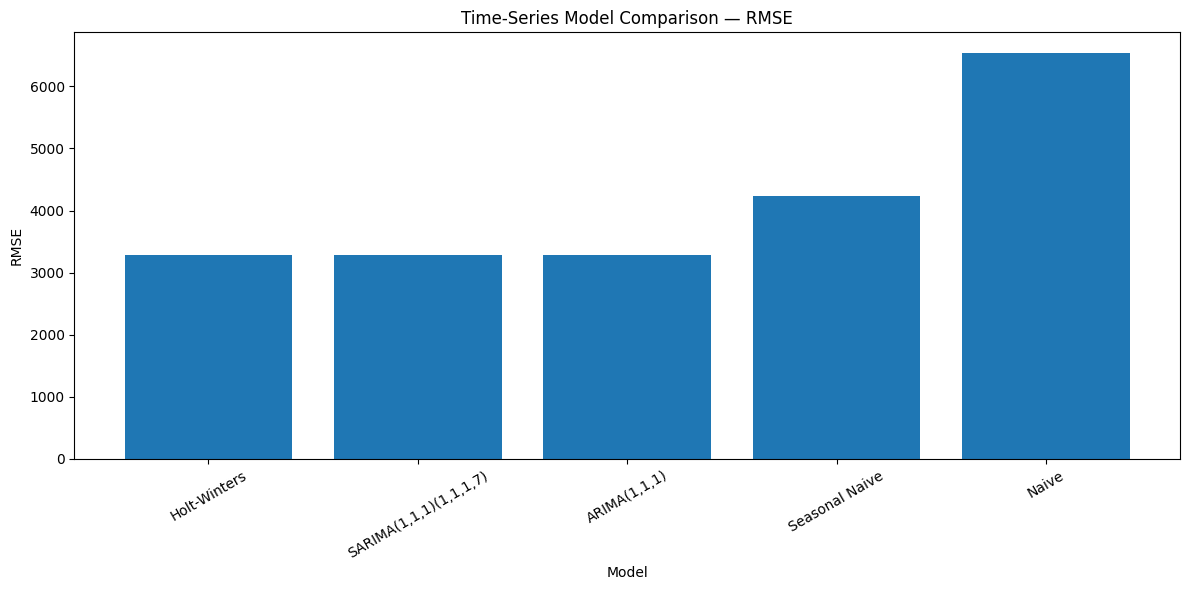

In [81]:
plt.figure(figsize=(12, 6))

plt.bar(
    model_results['Model'],
    model_results['RMSE']
)

plt.title("Time-Series Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "19_model_comparison_rmse.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## We see from the above that the Hol-Winters forecast gives the best output in terms of RMSE (Least RMSE)

# Actual vs all forecasts

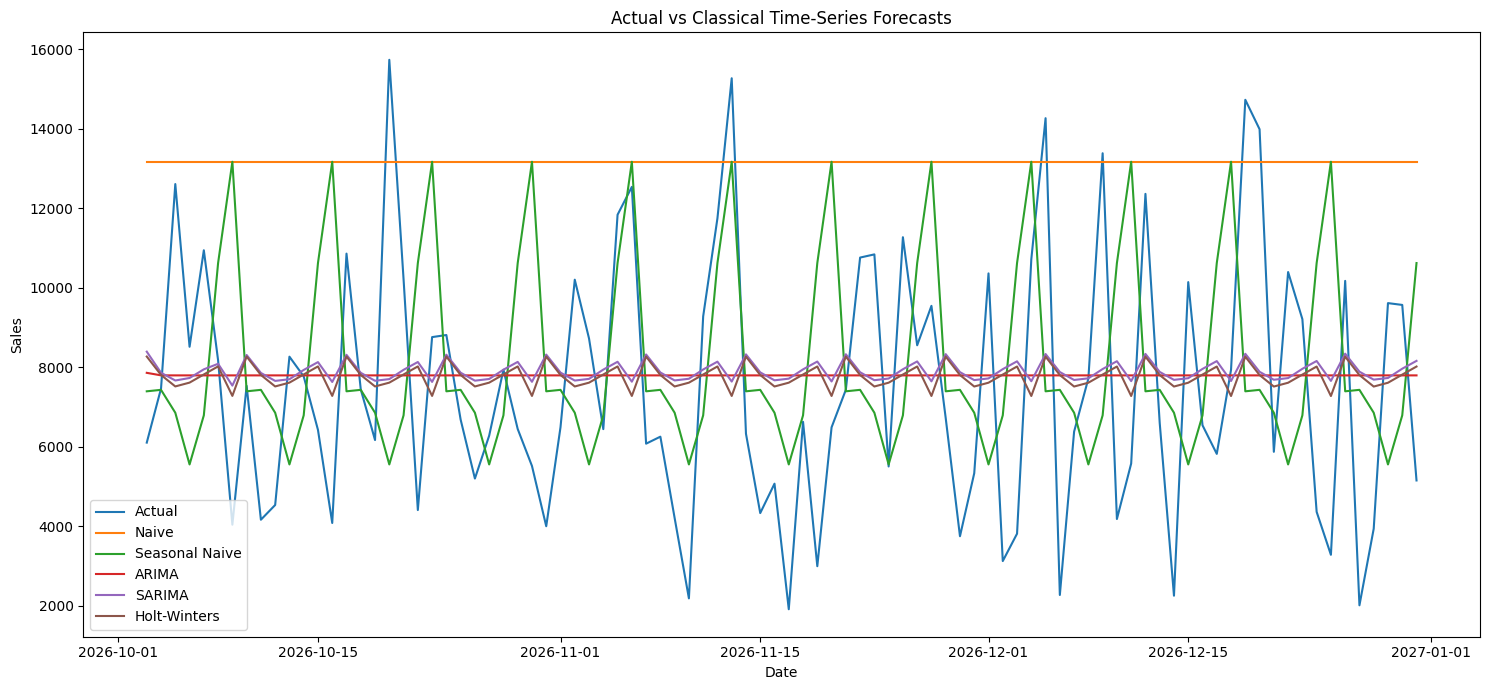

In [82]:
plt.figure(figsize=(15, 7))

plt.plot(
    test.index,
    test.values,
    label='Actual'
)

plt.plot(
    test.index,
    naive_forecast,
    label='Naive'
)

plt.plot(
    test.index,
    seasonal_naive_forecast,
    label='Seasonal Naive'
)

plt.plot(
    test.index,
    arima_forecast,
    label='ARIMA'
)

plt.plot(
    test.index,
    sarima_forecast,
    label='SARIMA'
)

plt.plot(
    test.index,
    hw_forecast,
    label='Holt-Winters'
)

plt.title("Actual vs Classical Time-Series Forecasts")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "20_actual_vs_all_models.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Selecting the best model

We'll select based on lowest RMSE.

In [83]:
best_model_name = model_results.iloc[0]['Model']

print("Best model based on RMSE:")
print(best_model_name)

Best model based on RMSE:
Holt-Winters


## Residual analysis

For the final model, we need to examine whether the residuals resemble white noise.

First select the residuals:

In [84]:
if best_model_name == 'ARIMA(1,1,1)':

    best_forecast = arima_forecast
    best_result = arima_result

elif best_model_name == 'SARIMA(1,1,1)(1,1,1,7)':

    best_forecast = sarima_forecast
    best_result = sarima_result

elif best_model_name == 'Holt-Winters':

    best_forecast = hw_forecast
    best_result = hw_result

elif best_model_name == 'Seasonal Naive':

    best_forecast = seasonal_naive_forecast
    best_result = None

else:

    best_forecast = naive_forecast
    best_result = None

## Residuals

In [85]:
residuals = test - best_forecast

print(residuals.describe())

count      90.000000
mean     -258.668700
std      3286.059240
min     -5792.344068
25%     -2413.222151
50%     -1128.581326
75%      2201.632698
max      8122.196004
dtype: float64


In [86]:
residuals.head()

Order_Date
2026-10-03   -2165.683975
2026-10-04    -341.758771
2026-10-05    5091.481416
2026-10-06     902.153554
2026-10-07    3124.497460
Freq: D, dtype: float64

In [87]:
residuals.shape

(90,)

In [88]:
residuals.info()

<class 'pandas.Series'>
DatetimeIndex: 90 entries, 2026-10-03 to 2026-12-31
Freq: D
Series name: None
Non-Null Count  Dtype  
--------------  -----  
90 non-null     float64
dtypes: float64(1)
memory usage: 1.4 KB


In [89]:
residuals.describe()

count      90.000000
mean     -258.668700
std      3286.059240
min     -5792.344068
25%     -2413.222151
50%     -1128.581326
75%      2201.632698
max      8122.196004
dtype: float64

## Residual time-series plot

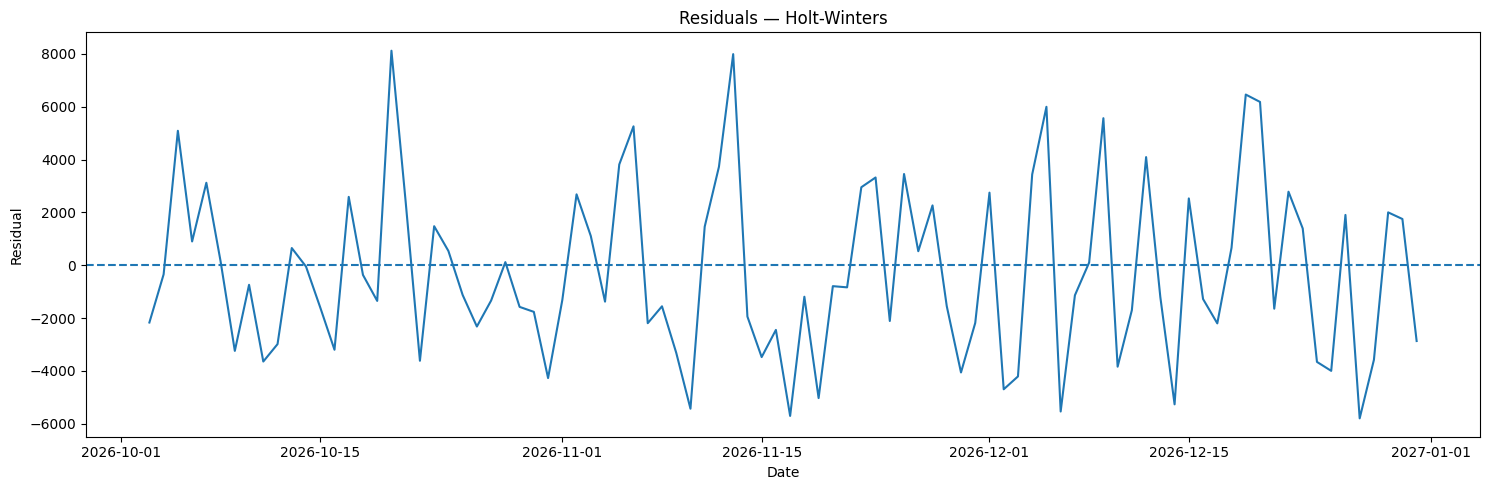

In [90]:
plt.figure(figsize=(15, 5))

plt.plot(
    residuals.index,
    residuals.values
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    f"Residuals — {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("Residual")

plt.tight_layout()

plt.savefig(
    "21_final_model_residuals.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Residual Distribution

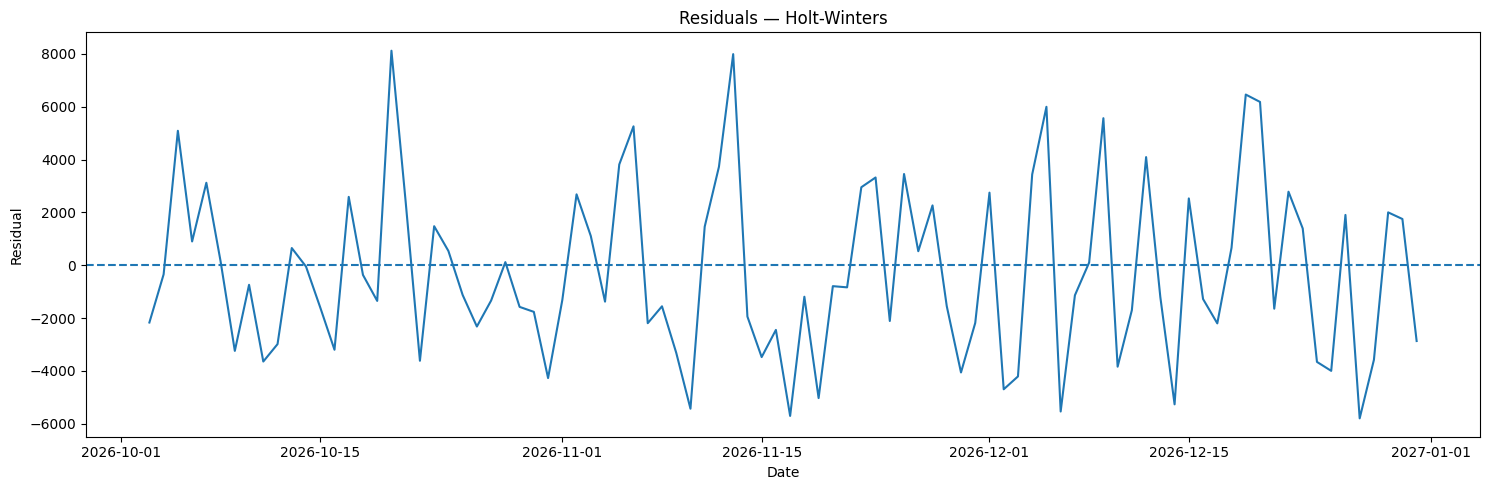

In [91]:
plt.figure(figsize=(15, 5))

plt.plot(
    residuals.index,
    residuals.values
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    f"Residuals — {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("Residual")

plt.tight_layout()

plt.savefig(
    "21_final_model_residuals.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Residual ACF

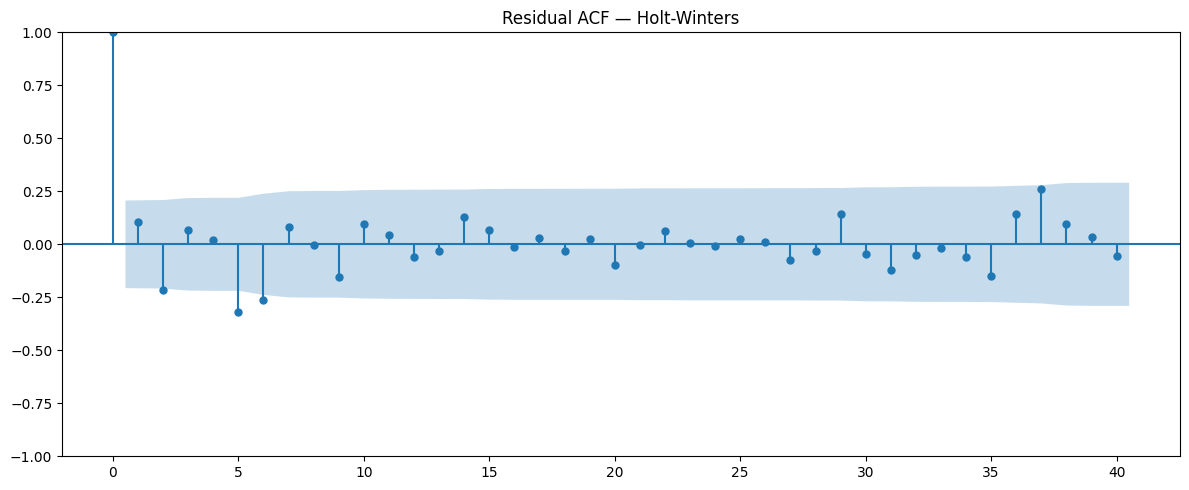

In [92]:
plt.figure(figsize=(12, 5))

plot_acf(
    residuals.dropna(),
    lags=40,
    ax=plt.gca()
)

plt.title(
    f"Residual ACF — {best_model_name}"
)

plt.tight_layout()

plt.savefig(
    "23_final_model_residual_acf.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Ideally, the residual autocorrelations should mostly lie within the confidence bounds.

## Residual PACF

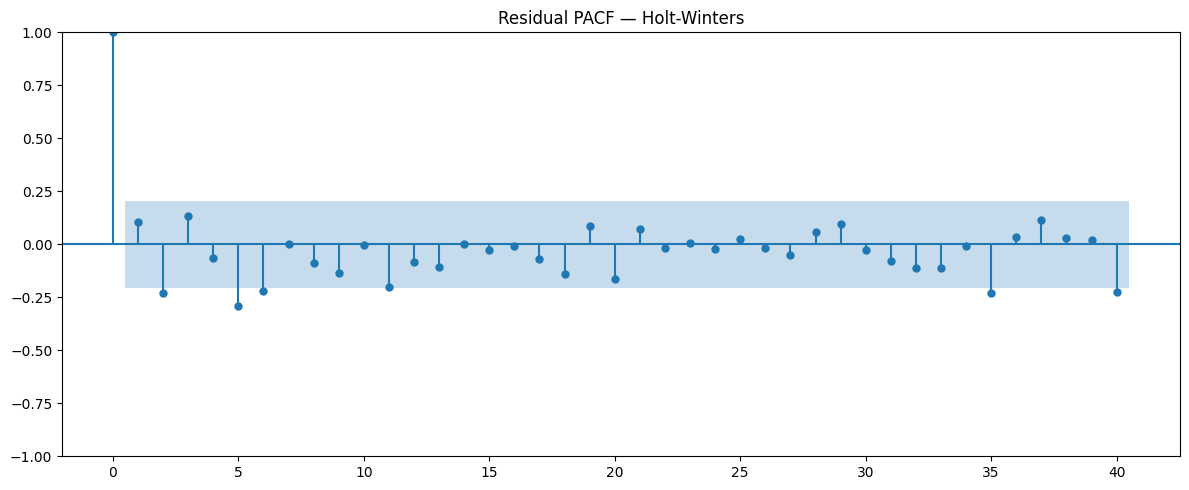

In [93]:
plt.figure(figsize=(12, 5))

plot_pacf(
    residuals.dropna(),
    lags=40,
    ax=plt.gca(),
    method='ywm'
)

plt.title(
    f"Residual PACF — {best_model_name}"
)

plt.tight_layout()

plt.savefig(
    "24_final_model_residual_pacf.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Ljung-Box test

This checks whether there is significant remaining autocorrelation in the residuals.

In [94]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[7, 14, 21, 28],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
7   23.395497   0.001454
14  29.279923   0.009576
21  31.272975   0.069233
28  32.685744   0.247509


p-value > 0.05
→ residuals do not show significant autocorrelation
→ good sign

p-value < 0.05
→ remaining autocorrelation exists
→ model may be improved

# Refit the selected model on the entire dataset

After evaluating the models, we use the best model on all available historical observations before producing future forecasts.

In [96]:
if best_model_name == 'ARIMA(1,1,1)':

    final_model = ARIMA(
        daily_sales,
        order=(1, 1, 1)
    )

    final_result = final_model.fit()

elif best_model_name == 'SARIMA(1,1,1)(1,1,1,7)':

    final_model = SARIMAX(
        daily_sales,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    final_result = final_model.fit(
        disp=False
    )

elif best_model_name == 'Holt-Winters':

    final_model = ExponentialSmoothing(
        daily_sales,
        trend='add',
        seasonal='add',
        seasonal_periods=7,
        initialization_method='estimated'
    )

    final_result = final_model.fit(
        optimized=True
    )

else:

    final_result = None

In [98]:
print(final_result)

In [99]:
print(final_model)

# Forecast the next week, month and year

We will use:

Next week = 7 days
Next month = 30 days
Next year = 365 days

## Generate all forecasts

In [101]:
last_date = daily_sales.index[-1]

forecast_7 = final_result.forecast(
    steps=7
)

forecast_30 = final_result.forecast(
    steps=30
)

forecast_365 = final_result.forecast(
    steps=365
)

# Creating forecast dataframes

In [103]:
forecast_week = pd.DataFrame({
    'Date': pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=7,
        freq='D'
    ),
    'Forecast_Sales': forecast_7.values
})

forecast_month = pd.DataFrame({
    'Date': pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=30,
        freq='D'
    ),
    'Forecast_Sales': forecast_30.values
})

forecast_year = pd.DataFrame({
    'Date': pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=365,
        freq='D'
    ),
    'Forecast_Sales': forecast_365.values
})

In [104]:
forecast_week.shape

(7, 2)

In [106]:
forecast_month.shape

(30, 2)

In [107]:
forecast_year.shape

(365, 2)

In [108]:
forecast_week.head()

,Date,Forecast_Sales
0,2027-01-01,7586.834367
1,2027-01-02,8577.610510
2,2027-01-03,7219.954737
3,2027-01-04,6990.362400
4,2027-01-05,7789.868767


In [109]:
forecast_month.head()

,Date,Forecast_Sales
0,2027-01-01,7586.834367
1,2027-01-02,8577.610510
2,2027-01-03,7219.954737
3,2027-01-04,6990.362400
4,2027-01-05,7789.868767


In [110]:
forecast_year.head()

,Date,Forecast_Sales
0,2027-01-01,7586.834367
1,2027-01-02,8577.610510
2,2027-01-03,7219.954737
3,2027-01-04,6990.362400
4,2027-01-05,7789.868767


In [111]:
forecast_week.describe()

,Date,Forecast_Sales
count,7,7.000000
mean,2027-01-04 00:00:00,7672.212148
min,2027-01-01 00:00:00,6990.362400
25%,2027-01-02 12:00:00,7326.778214
50%,2027-01-04 00:00:00,7586.834367
75%,2027-01-05 12:00:00,7948.560667
max,2027-01-07 00:00:00,8577.610510
std,NaN,541.068326


In [112]:
forecast_month.describe()

,Date,Forecast_Sales
count,30,30.000000
mean,2027-01-15 12:00:00,7698.016442
min,2027-01-01 00:00:00,6987.608893
25%,2027-01-08 06:00:00,7272.678099
50%,2027-01-15 12:00:00,7585.457613
75%,2027-01-22 18:00:00,8105.187437
max,2027-01-30 00:00:00,8577.610510
std,NaN,519.524533


In [113]:
forecast_year.describe()

,Date,Forecast_Sales
count,365,365.000000
mean,2027-07-02 00:00:00,7648.506795
min,2027-01-01 00:00:00,6943.552791
25%,2027-04-02 00:00:00,7208.940712
50%,2027-07-02 00:00:00,7562.970644
75%,2027-10-01 00:00:00,8071.456984
max,2027-12-31 00:00:00,8577.610510
std,NaN,501.154194


## Displaying next-week forecast

In [114]:
print("NEXT 7 DAYS FORECAST")
print("====================")

display(forecast_week)

NEXT 7 DAYS FORECAST


,Date,Forecast_Sales
0,2027-01-01,7586.834367
1,2027-01-02,8577.610510
2,2027-01-03,7219.954737
3,2027-01-04,6990.362400
4,2027-01-05,7789.868767
5,2027-01-06,8107.252567
6,2027-01-07,7433.601692


In [115]:
# Displaying next-month forecast

print("NEXT 30 DAYS FORECAST")
print("=====================")

display(forecast_month)

NEXT 30 DAYS FORECAST


,Date,Forecast_Sales
0,2027-01-01,7586.834367
1,2027-01-02,8577.610510
2,2027-01-03,7219.954737
3,2027-01-04,6990.362400
4,2027-01-05,7789.868767
5,2027-01-06,8107.252567
6,2027-01-07,7433.601692
7,2027-01-08,7585.916531
8,2027-01-09,8576.692675
9,2027-01-10,7219.036902


## Displaying next-year forecast

In [116]:
print("NEXT 365 DAYS FORECAST")
print("======================")

display(forecast_year)

NEXT 365 DAYS FORECAST


,Date,Forecast_Sales
0,2027-01-01,7586.834367
1,2027-01-02,8577.610510
2,2027-01-03,7219.954737
3,2027-01-04,6990.362400
4,2027-01-05,7789.868767
...,...,...
360,2027-12-27,6943.552791
361,2027-12-28,7743.059158
362,2027-12-29,8060.442958
363,2027-12-30,7386.792083


## Saving Forecasts

In [117]:
forecast_week.to_csv(
    "forecast_next_7_days.csv",
    index=False
)

forecast_month.to_csv(
    "forecast_next_30_days.csv",
    index=False
)

forecast_year.to_csv(
    "forecast_next_365_days.csv",
    index=False
)

print("Forecast files saved successfully.")

Forecast files saved successfully.


## Plotting next week's forecast

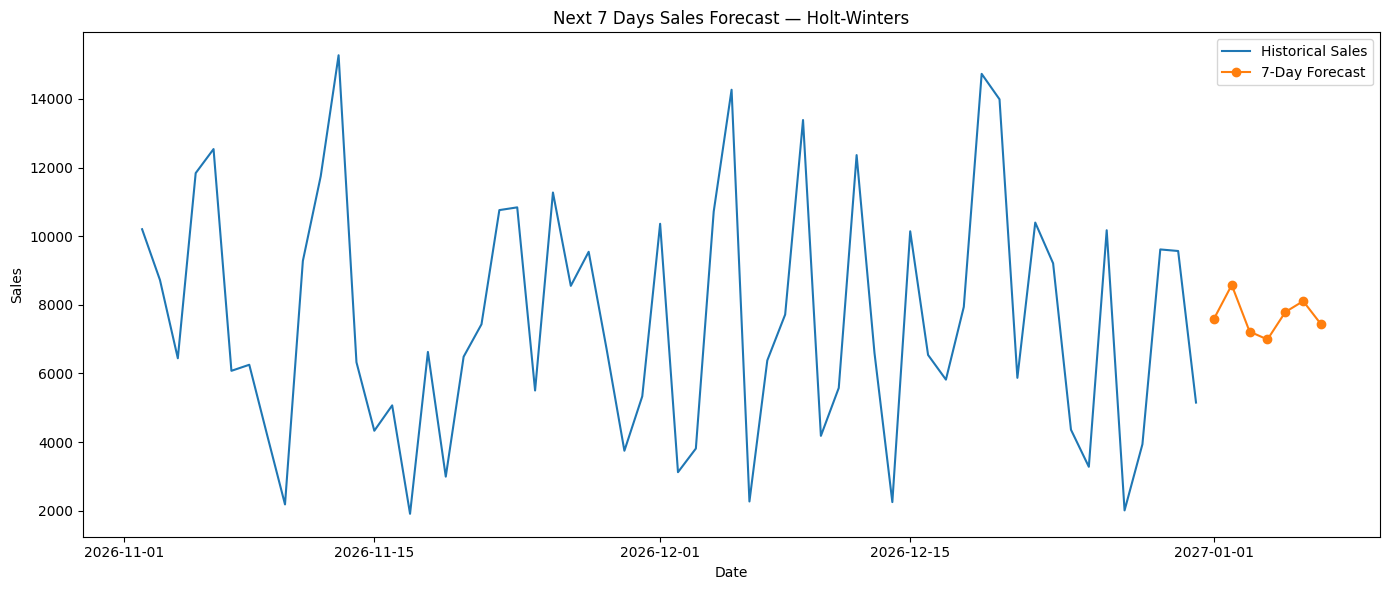

In [118]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales.iloc[-60:].index,
    daily_sales.iloc[-60:].values,
    label='Historical Sales'
)

plt.plot(
    forecast_week['Date'],
    forecast_week['Forecast_Sales'],
    marker='o',
    label='7-Day Forecast'
)

plt.title(
    f"Next 7 Days Sales Forecast — {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "26_forecast_next_7_days.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Plotting next month's forecast

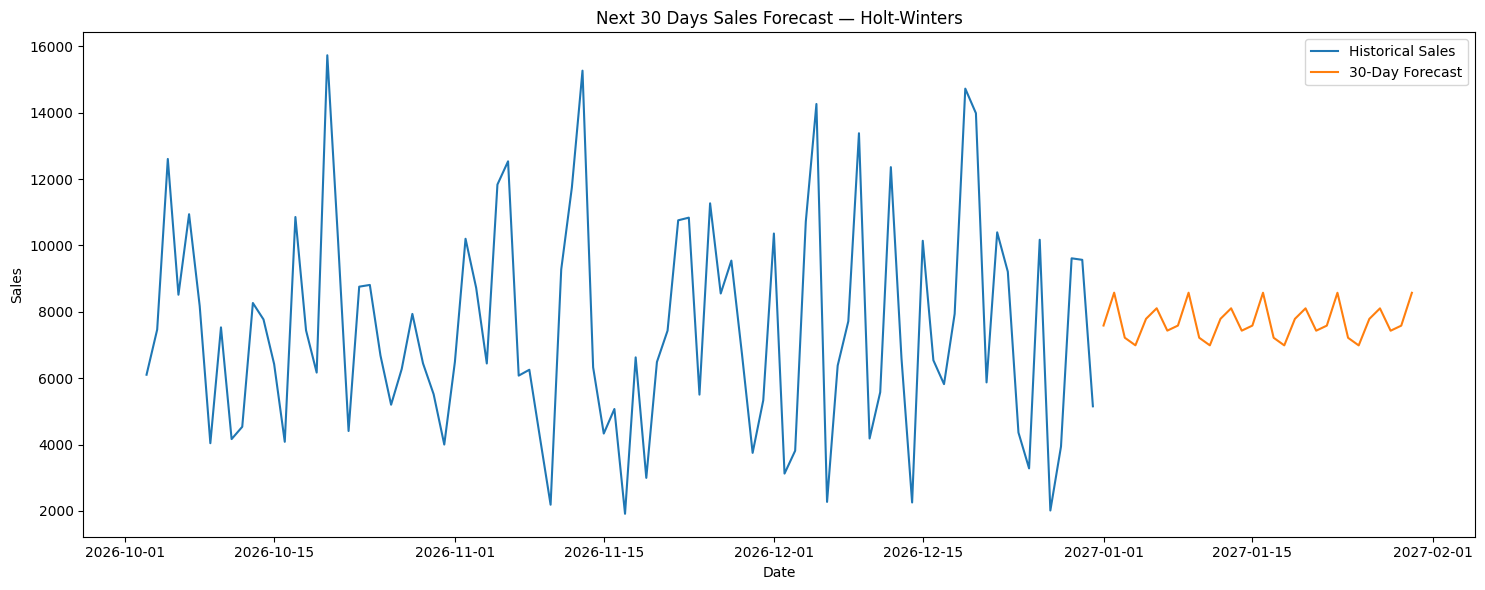

In [119]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales.iloc[-90:].index,
    daily_sales.iloc[-90:].values,
    label='Historical Sales'
)

plt.plot(
    forecast_month['Date'],
    forecast_month['Forecast_Sales'],
    label='30-Day Forecast'
)

plt.title(
    f"Next 30 Days Sales Forecast — {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "27_forecast_next_30_days.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Plot next year's forecast

For a one-year forecast, plotting all 365 daily observations against four years of historical daily observations can become difficult to read.

Therefore, we'll display the last year of historical data plus the next year's forecast. 

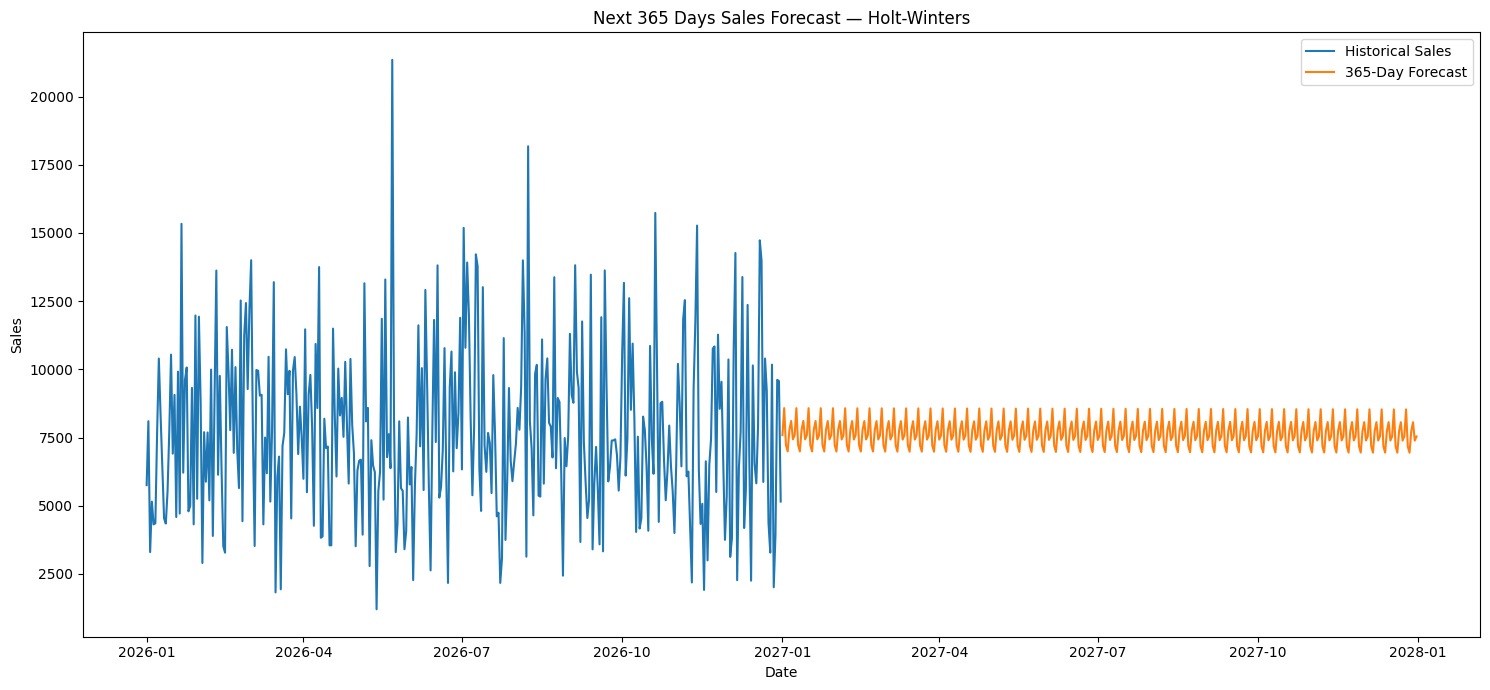

In [120]:
plt.figure(figsize=(15, 7))

plt.plot(
    daily_sales.iloc[-365:].index,
    daily_sales.iloc[-365:].values,
    label='Historical Sales'
)

plt.plot(
    forecast_year['Date'],
    forecast_year['Forecast_Sales'],
    label='365-Day Forecast'
)

plt.title(
    f"Next 365 Days Sales Forecast — {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "28_forecast_next_365_days.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Monthly view of the annual forecast

This offers a useful display for the one-year forecast.

In [121]:
forecast_year_monthly = (
    forecast_year
    .set_index('Date')
    .resample('ME')['Forecast_Sales']
    .sum()
)

print(forecast_year_monthly)

Date
2027-01-31    238156.776656
2027-02-28    214669.579469
2027-03-31    237421.223554
2027-04-30    229443.117787
2027-05-31    237072.934055
2027-06-30    230080.248005
2027-07-31    237635.237400
2027-08-31    235911.633276
2027-09-30    229362.353755
2027-10-31    237047.113574
2027-11-30    228361.257770
2027-12-31    236543.504844
Freq: ME, Name: Forecast_Sales, dtype: float64


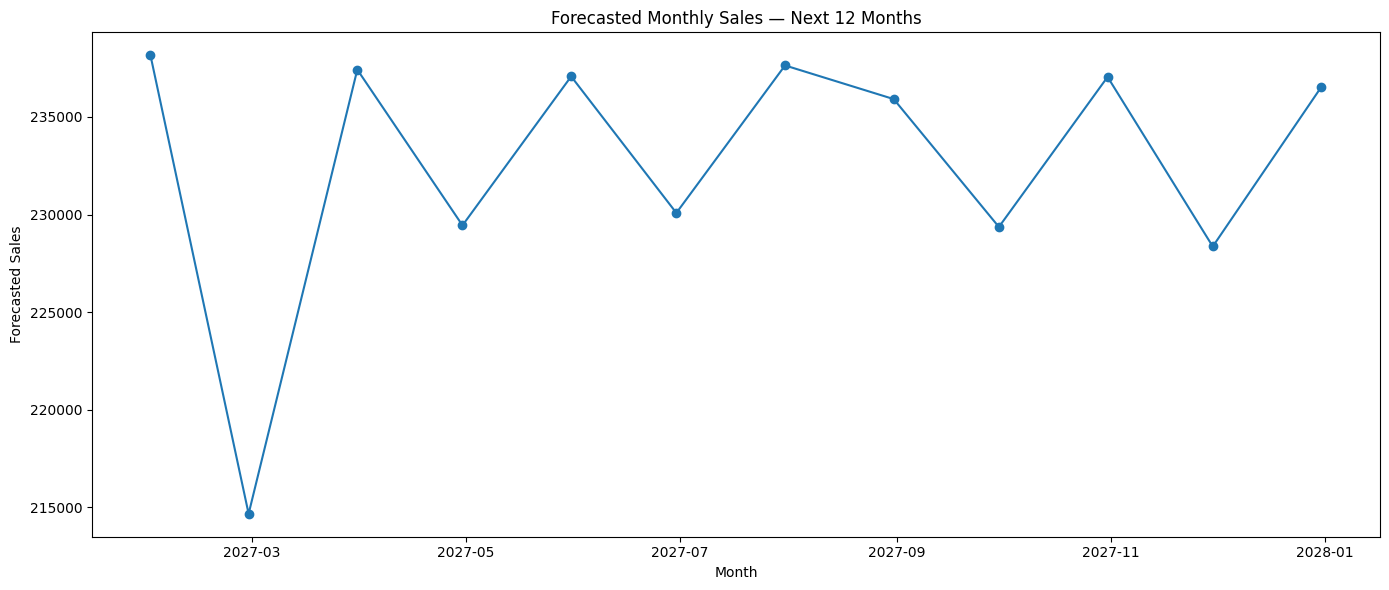

In [122]:
plt.figure(figsize=(14, 6))

plt.plot(
    forecast_year_monthly.index,
    forecast_year_monthly.values,
    marker='o'
)

plt.title(
    "Forecasted Monthly Sales — Next 12 Months"
)

plt.xlabel("Month")
plt.ylabel("Forecasted Sales")

plt.tight_layout()

plt.savefig(
    "29_forecast_next_12_months_monthly.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Final forecast summary

In [123]:
forecast_summary = pd.DataFrame({
    'Forecast_Horizon': [
        'Next 7 Days',
        'Next 30 Days',
        'Next 365 Days'
    ],

    'Total_Forecasted_Sales': [
        forecast_week['Forecast_Sales'].sum(),
        forecast_month['Forecast_Sales'].sum(),
        forecast_year['Forecast_Sales'].sum()
    ],

    'Average_Daily_Forecast': [
        forecast_week['Forecast_Sales'].mean(),
        forecast_month['Forecast_Sales'].mean(),
        forecast_year['Forecast_Sales'].mean()
    ]
})

print(forecast_summary)

  Forecast_Horizon  Total_Forecasted_Sales  Average_Daily_Forecast
0      Next 7 Days            5.370549e+04             7672.212148
1     Next 30 Days            2.309405e+05             7698.016442
2    Next 365 Days            2.791705e+06             7648.506795


## Saving the Forecast Summary

In [124]:
forecast_summary.to_csv(
    "forecast_summary.csv",
    index=False
)

# Serializing the final classical time-series model

In [125]:
import pickle

with open(
    "final_time_series_model.pkl",
    "wb"
) as file:

    pickle.dump(
        final_result,
        file
    )

print("Model saved as final_time_series_model.pkl")

Model saved as final_time_series_model.pkl
